# TinyTroupe Demo: Gen Z Skincare Concept Test

A concept test for a Gen Z US skincare product over a 10-persona panel synthesized by `TinyPersonFactory` from `usa.json` demographics (Microsoft factory idiom).

Paralleled by [`claude-persona/demo/genz-skincare/`](../claude-persona/demo/genz-skincare/) (different engine, different persona construction) for a side-by-side comparison.

## Concept test structure

- **A**: Acne Control Serum — fights breakouts with clinically proven actives
- **B**: Barrier Repair Cream — strengthens skin barrier and reduces redness
- **C**: Glow Boosting Toner — three copy variants tested (C1 / C2 / C3)

## Stages

1. **Stage 1 (C1)**: `C: brightens dull skin and evens skin tone`
2. **Stage 2 (C2, conditional)**: if C1 still scored 0, try `C: brightens dull skin and supports a more even complexion`
3. **Stage 3 (C3)**: `C: visibly brightens dull skin for a radiant, even complexion`

## Reference

- Claude-persona baseline (Sonnet, hand-curated 10 personas): A=3, B=4, C=3, mean purchase likelihood 3.3 / 5.
- Default model here: `gpt-5-mini` (TinyTroupe 0.7.0 default).
- See `Doc/2026-04-21_tinytroupe_genz_skincare_learnings.md` for the full writeup.

In [1]:
import os
# OPENAI_API_KEY must be in the shell env before launching Jupyter.
assert os.environ.get("OPENAI_API_KEY"), "Please set OPENAI_API_KEY in your shell before running."

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from tinytroupe.agent import TinyPerson
from tinytroupe.environment import TinyWorld
from tinytroupe.extraction import ResultsExtractor
import tinytroupe.control as control


!!!!
DISCLAIMER: TinyTroupe relies on Artificial Intelligence (AI) models to generate content. 
The AI models are not perfect and may produce inappropriate or inaccurate results. 
For any serious or consequential use, please review the generated content before using it.
!!!!

Looking for default config on: /Users/take/Develop/TinyTroupe/TinyTroupe/tinytroupe/utils/../config.ini
Found custom config on: /Users/take/Develop/TinyTroupe/effective-persona-simulation/config.ini
TinyTroupe version: 0.7.0
Current date and time (local): 2026-04-21 16:03:07
Current date and time (UTC):   2026-04-21 20:03:07

Current TinyTroupe configuration 
[OpenAI]
api_type = openai
azure_api_version = 2024-08-01-preview
model = gpt-5-mini
reasoning_model = o3-mini
vision_detail = auto
embedding_model = text-embedding-3-small
azure_embedding_model_api_version = 2023-05-15
max_completion_tokens = 128000
timeout = 480
max_attempts = 5
waiting_time = 0
exponential_backoff_factor = 5
max_concurrent_model_calls = 4

In [ ]:
control.begin('cache_genz_skincare_c1.json')

## 1. Load the persona panel

10 Gen Z personas synthesized earlier via `TinyPersonFactory.create_factory_from_demography(usa.json)` (Microsoft idiom), saved to disk, and reused here.

In [ ]:
PANEL_DIR = "exported_genz_skincare_personas"

def load_panel():
    TinyPerson.clear_agents()
    return TinyPerson.load_specifications_from_folder(
        PANEL_DIR,
        file_suffix=".json",
        suppress_memory=True,
    )

panel = load_panel()
print(f"\u2705 Loaded {len(panel)} personas from {PANEL_DIR}/")
for a in panel:
    occ = a.get("occupation")
    occ_title = occ.get("title") if isinstance(occ, dict) else occ
    print(f"  - {a.get('name')} | age {a.get('age')} | {occ_title}")

## 2. Stage 1 — concept test with stronger C copy

`C: Glow Boosting Toner — brightens dull skin and evens skin tone`

In [5]:
%%time
CONCEPTS_C1 = """
**Option A: Acne Control Serum** \u2014 fights breakouts with clinically proven actives.

**Option B: Barrier Repair Cream** \u2014 strengthens skin barrier and reduces redness.

**Option C: Glow Boosting Toner** \u2014 brightens dull skin and evens skin tone.
"""

run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")

for i, agent in enumerate(panel, start=1):
    print(f"[C1 {i}/{len(panel)}] Interviewing: {agent.get('name')}...")
    world = TinyWorld(f"Retest_C1_Room_{run_ts}_{i}", [agent])
    world.broadcast("Welcome. I'd like your reaction to three new skincare product concepts we're developing.")
    world.broadcast(
        f"Here are the three concepts:\n{CONCEPTS_C1}\n\n"
        "Which ONE (A, B, or C) is your top choice? Please explain why, how likely you'd actually be to buy it, "
        "and what one thing you'd change about it to make it better."
    )
    world.run(1)
    print(f"    \u2713 done")

[C1 1/10] Interviewing: Logan Reid Mitchell...


USER --> Logan Reid Mitchell: [CONVERSATION] 
          > Welcome. I'd like your reaction to three new skincare product concepts we're developing.

USER --> Logan Reid Mitchell: [CONVERSATION] 
          > Here are the three concepts:  **Option A: Acne Control Serum** — fights breakouts with
          > clinically proven actives.  **Option B: Barrier Repair Cream** — strengthens skin
          > barrier and reduces redness.  **Option C: Glow Boosting Toner** — brightens dull skin
          > and evens skin tone.   Which ONE (A, B, or C) is your top choice? Please explain why,
          > how likely you'd actually be to buy it, and what one thing you'd change about it to make
          > it better.

2026-04-21 16:03:12,117 - MainThread(8757062720) - tinytroupe - INFO - [Retest_C1_Room_20260421_160312_1] Running world simulation step 1 of 1.


────────────────────────────────── Retest_C1_Room_20260421_160312_1 step 1 of 1 ───────────────────────────────────

...

2026-04-21 16:11:52,825 - ThreadPoolExecutor-10_0(6418657280) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Hana Park acts: [THINK] 
               > Okay—quick compare. Option A (Acne Control Serum): strong appeal because
               > 'clinically proven actives' speak to my ingredient-literacy and shoppers who want
               > results. Risk: many acne actives are drying/irritating and can worsen PIH if not
               > buffered; would need hydrating + soothing offsets and clear concentration info.
               > Option B (Barrier Repair Cream): aligns with my daily beliefs (barrier health
               > prevents irritation/PIH), lower risk, broader audience, pairs well with actives,
               > and fits my personal routine (I already use ceramide-rich night cream). Option C
               > (Glow Boosting Toner): tempting for 'glass skin' crowd—brightening toners can be
               > useful, but claims often overpromise; formulation details (active type, pH,
               > packaging to protect actives) matter a lot. Choosing top pick: B. Rationale:
               > preventative products that protect barrier reduce downstream problems (breakouts,
               > redness, PIH) and are something I and many shoppers will repurchase regularly.
               > Likelihood to buy: high (I personally would buy it and recommend to custo (...)

Hana Park acts: [TALK] 
               > My top choice is Option B: Barrier Repair Cream. Reason: as someone who prioritizes
               > preventing PIH and who sells/recommends products to lots of customers, a barrier-
               > first product solves a lot of downstream problems (less redness, fewer flares from
               > actives, better tolerance of retinol/AHAs). It's broadly useful for
               > normal/combination and sensitive-leaning skin types and feels like a product people
               > will repurchase regularly. How likely I'd buy it: very likely—I'd give it an
               > 8.5–9/10, especially if the texture is lightweight and it layers well under makeup.
               > One thing I'd change to make it better: reformulate/position it as a lightweight
               > gel-cream (no greasy finish), fragrance-free, with a transparent ingredient callout
               > (ceramides + cholesterol + a gentle % of niacinamide + panthenol/centella), and
               > include travel/sample sizes for patch-testing. Also add clear directions on how to
               > layer it with active actives (so customers don't accidentally over-exfoliate) and a
               > simple clinical claim (e.g., reduces TEWL or visibl (...)

Hana Park acts: [DONE] 
               > Finished — waiting for follow-up or to help draft packaging claims/marketing copy.

    ✓ done
CPU times: user 1.97 s, sys: 1.09 s, total: 3.06 s
Wall time: 8min 40s


In [ ]:
extractor = ResultsExtractor()

def extract_concept_results(panel, situation):
    rows = []
    for agent in panel:
        extraction = extractor.extract_results_from_agent(
            agent,
            extraction_objective="Extract the persona's concept-test choice, reasoning, purchase likelihood and improvement suggestion.",
            situation=situation,
            fields=["preferred_option", "reasoning", "purchase_likelihood", "improvement"],
        )
        if extraction is None:
            continue
        raw_opt = str(extraction.get("preferred_option", ""))
        m = re.search(r"[ABC]", raw_opt.upper())
        preferred = m.group(0) if m else None
        raw_lk = extraction.get("purchase_likelihood")
        try:
            likelihood = int(re.search(r"\d", str(raw_lk)).group(0)) if raw_lk is not None else None
        except Exception:
            likelihood = None
        occ = agent.get("occupation")
        occ_title = occ.get("title") if isinstance(occ, dict) else occ
        rows.append({
            "name": agent.get("name"),
            "age": agent.get("age"),
            "gender": agent.get("gender"),
            "occupation": occ_title,
            "preferred_option": preferred,
            "reasoning": extraction.get("reasoning"),
            "purchase_likelihood": likelihood,
            "improvement": extraction.get("improvement"),
        })
    return pd.DataFrame(rows)

c1_df = extract_concept_results(panel, "Concept test with C copy variant C1 (brightens dull skin and evens skin tone). A: Acne Control Serum, B: Barrier Repair Cream, C: Glow Boosting Toner.")
c1_df.to_csv("result_genz_skincare_concept_c1.csv", index=False)
display(c1_df)

c1_counts = c1_df['preferred_option'].value_counts().reindex(['A', 'B', 'C']).fillna(0).astype(int)
print(f"\nStage 1 (C1) counts: A={c1_counts['A']} B={c1_counts['B']} C={c1_counts['C']}")

In [7]:
control.checkpoint()

## 3. Stage 2 (conditional) — further-strengthened C copy

Runs only if C1 still produced 0 votes for C. C copy becomes *'brightens dull skin and supports a more even complexion'*. Personas are reloaded from disk so they don't carry episodic memory of stage 1 into stage 2.

In [ ]:
%%time
c2_df = None
c2_counts = None

if c1_counts['C'] == 0:
    print("Stage 1 (C1) scored C=0 — proceeding to Stage 2 (C2).\n")

    # Reset TinyTroupe's simulation state so we can freshly reload personas
    # without the agent-name collision from Stage 1.
    control.end()
    control.reset()
    TinyPerson.clear_agents()
    control.begin('cache_genz_skincare_c2.json')

    CONCEPTS_C2 = """
**Option A: Acne Control Serum** — fights breakouts with clinically proven actives.

**Option B: Barrier Repair Cream** — strengthens skin barrier and reduces redness.

**Option C: Glow Boosting Toner** — brightens dull skin and supports a more even complexion.
"""

    panel2 = load_panel()   # fresh agents, no C1 memory
    run_ts2 = datetime.now().strftime("%Y%m%d_%H%M%S")
    for i, agent in enumerate(panel2, start=1):
        print(f"[C2 {i}/{len(panel2)}] Interviewing: {agent.get('name')}...")
        world = TinyWorld(f"C2_Room_{run_ts2}_{i}", [agent])
        world.broadcast("Welcome. I'd like your reaction to three new skincare product concepts we're developing.")
        world.broadcast(
            f"Here are the three concepts:\n{CONCEPTS_C2}\n\n"
            "Which ONE (A, B, or C) is your top choice? Please explain why, how likely you'd actually be to buy it, "
            "and what one thing you'd change about it to make it better."
        )
        world.run(1)
        print(f"    ✓ done")

    c2_df = extract_concept_results(panel2, "Concept test with C copy variant C2 (brightens dull skin and supports a more even complexion). A: Acne Control Serum, B: Barrier Repair Cream, C: Glow Boosting Toner.")
    c2_df.to_csv("result_genz_skincare_concept_c2.csv", index=False)
    display(c2_df)

    c2_counts = c2_df['preferred_option'].value_counts().reindex(['A', 'B', 'C']).fillna(0).astype(int)
    print(f"\nStage 2 (C2) counts: A={c2_counts['A']} B={c2_counts['B']} C={c2_counts['C']}")
else:
    print(f"Stage 1 (C1) already gave C={c1_counts['C']} votes — skipping Stage 2.")

## 4. Stage 3 — strongest C copy

`C: Glow Boosting Toner — visibly brightens dull skin for a radiant, even complexion`

Runs unconditionally (regardless of C1/C2 outcome) as an additional data point. Fresh personas re-loaded from disk so no episodic memory leak from earlier stages.

In [ ]:
%%time
# Stage 3: unconditional run with the strongest C copy.
# Reset simulation state so we can cleanly reload personas again.
control.end()
control.reset()
TinyPerson.clear_agents()
control.begin('cache_genz_skincare_c3.json')

CONCEPTS_C3 = """
**Option A: Acne Control Serum** — fights breakouts with clinically proven actives.

**Option B: Barrier Repair Cream** — strengthens skin barrier and reduces redness.

**Option C: Glow Boosting Toner** — visibly brightens dull skin for a radiant, even complexion.
"""

panel3 = load_panel()
run_ts3 = datetime.now().strftime("%Y%m%d_%H%M%S")
for i, agent in enumerate(panel3, start=1):
    print(f"[C3 {i}/{len(panel3)}] Interviewing: {agent.get('name')}...")
    world = TinyWorld(f"C3_Room_{run_ts3}_{i}", [agent])
    world.broadcast("Welcome. I'd like your reaction to three new skincare product concepts we're developing.")
    world.broadcast(
        f"Here are the three concepts:\n{CONCEPTS_C3}\n\n"
        "Which ONE (A, B, or C) is your top choice? Please explain why, how likely you'd actually be to buy it, "
        "and what one thing you'd change about it to make it better."
    )
    world.run(1)
    print(f"    ✓ done")

c3_df = extract_concept_results(panel3, "Concept test with C copy variant C3 (visibly brightens dull skin for a radiant, even complexion). A: Acne Control Serum, B: Barrier Repair Cream, C: Glow Boosting Toner.")
c3_df.to_csv("result_genz_skincare_concept_c3.csv", index=False)
display(c3_df)

c3_counts = c3_df['preferred_option'].value_counts().reindex(['A', 'B', 'C']).fillna(0).astype(int)
print(f"\nStage 3 (C3) counts: A={c3_counts['A']} B={c3_counts['B']} C={c3_counts['C']}")

## 5. Comparison across runs

Concept preference counts across runs:



,"claude-persona (Sonnet, N=10)",TinyTroupe v2 (original C copy),Retest C1 (evens skin tone),Retest C2 (supports even complexion),"Retest C3 (visibly brightens, radiant even complexion)"
A,3,4,4,4,4
B,4,6,6,5,6
C,3,0,0,1,0



Share of panel:



,"claude-persona (Sonnet, N=10)",TinyTroupe v2 (original C copy),Retest C1 (evens skin tone),Retest C2 (supports even complexion),"Retest C3 (visibly brightens, radiant even complexion)"
A,0.3,0.4,0.4,0.4,0.4
B,0.4,0.6,0.6,0.5,0.6
C,0.3,0.0,0.0,0.1,0.0


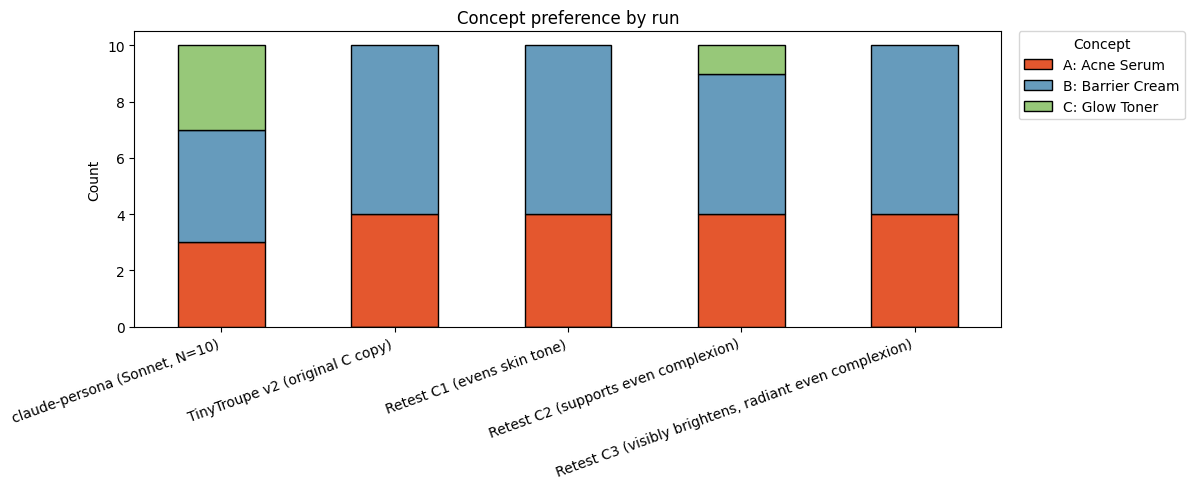


Mean purchase likelihood (raw, free-scale) — C1: 7.5
Mean purchase likelihood — C2: 7.9
Mean purchase likelihood — C3: 7.6


In [10]:
summary = {
    'claude-persona (Sonnet, N=10)':       pd.Series({'A': 3, 'B': 4, 'C': 3}),
    'TinyTroupe v2 (original C copy)':     pd.Series({'A': 4, 'B': 6, 'C': 0}),
    'Retest C1 (evens skin tone)':          c1_counts,
}
if c2_counts is not None:
    summary['Retest C2 (supports even complexion)'] = c2_counts
summary['Retest C3 (visibly brightens, radiant even complexion)'] = c3_counts

comparison = pd.DataFrame(summary)
print("Concept preference counts across runs:\n")
display(comparison)

# Share table
shares = comparison.div(comparison.sum(axis=0), axis=1).round(2)
print("\nShare of panel:\n")
display(shares)

# Chart
fig, ax = plt.subplots(figsize=(12, 5))
comparison.T.plot(kind='bar', stacked=True, ax=ax,
                  color=['#E4572E', '#669BBC', '#97C879'], edgecolor='black')
ax.set_title('Concept preference by run')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(title='Concept', labels=['A: Acne Serum', 'B: Barrier Cream', 'C: Glow Toner'],
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

# Mean purchase likelihood
def mean_pl(df):
    return df['purchase_likelihood'].dropna().mean() if df is not None and not df.empty else None

print(f"\nMean purchase likelihood (raw, free-scale) — C1: {mean_pl(c1_df)}")
if c2_df is not None:
    print(f"Mean purchase likelihood — C2: {mean_pl(c2_df)}")
print(f"Mean purchase likelihood — C3: {mean_pl(c3_df)}")

In [11]:
control.end()